# MNIST with PyTorch

In this notebook, we'll train a multi-layer perceptron (MLP) to classify handwritten digits. This is the classic "hello world" of deep learning -- but the real goal is to understand each step of the training loop: forward pass, loss, backward pass, and parameter update.

By the end of this notebook, you should be able to:

- Implement and train an MLP classifier using PyTorch
- Trace tensor shapes through each layer of the network
- Interpret training and validation loss *and accuracy* curves
- Visualize what the model has learned (predictions and weights)
- Explain why initial cross-entropy loss is approximately log(10)

### Course Objectives

TM-MLPParts, TM-DataFlow, TM-Implement-TrainingLoop, OG-LossFunctions, OG-Eval-Experiment

In [ ]:
import numpy as np
np.set_printoptions(precision=3)
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
%matplotlib inline

num_samples = 1000
max_iter = 100

## Load and Understand the Data

First, let's load the MNIST dataset. Each image is a 28x28 grid of grayscale pixels. Our job is to build a model that takes the 784 pixel values as input and predicts which digit (0-9) it represents.

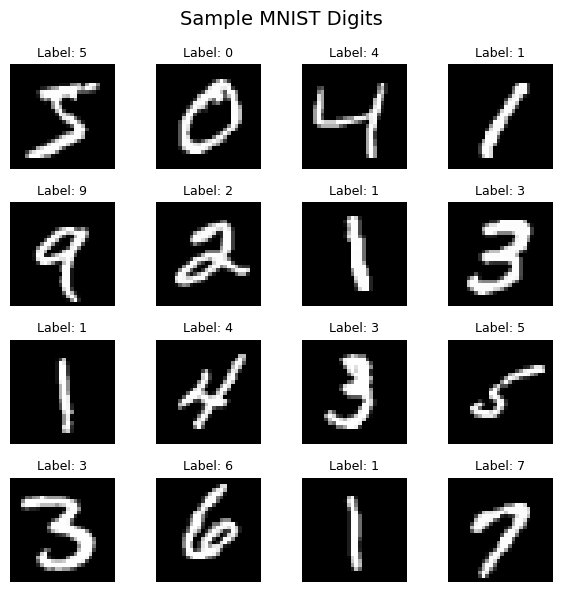

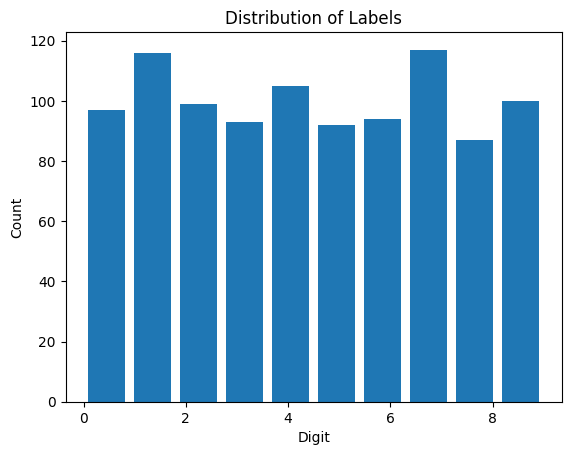

In [ ]:
# Load a subset of MNIST to start
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
x_full = mnist.data[:num_samples] / 255.0  # Scale pixel values to [0,1]
x_full = x_full.astype('float32')
y_full = mnist.target[:num_samples].astype(int)

# Show a grid of 16 sample images
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_full[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_full[i]}", fontsize=9)
    ax.axis('off')
fig.suptitle("Sample MNIST Digits", fontsize=14)
plt.tight_layout()

# Look at the distribution of labels
plt.figure()
plt.hist(y_full, bins=10, rwidth=0.8)
plt.title("Distribution of Labels")
plt.xlabel("Digit")
plt.ylabel("Count");

### Understanding Flattening

To use these images in our model, we need to "flatten" each 28x28 grid into a single vector of 784 numbers:

Shape after flattening: (784,)


Text(0, 0.5, 'Pixel value')

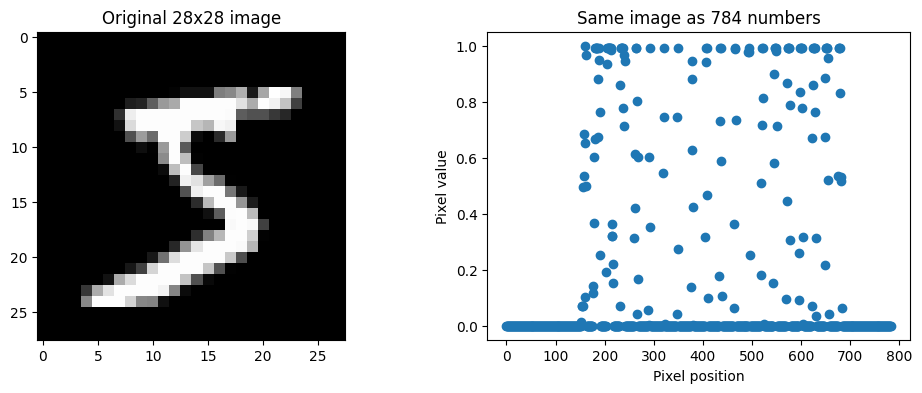

In [ ]:
# Demonstrate flattening on one image
single_image = x_full[0].reshape(28, 28)
flat_image = single_image.reshape(-1)  # -1 means "figure out this dimension"
print("Shape after flattening:", flat_image.shape)

# Visualize how flattening works
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(single_image, cmap='gray')
ax1.set_title("Original 28x28 image")
ax2.scatter(np.arange(784), flat_image)
ax2.set_title("Same image as 784 numbers")
ax2.set_xlabel("Pixel position")
ax2.set_ylabel("Pixel value")

Our dataset `x_full` was already flattened: each row is one flattened image:

In [ ]:
print("Full dataset shape:", x_full.shape)
print("Number of training examples:", x_full.shape[0])
print("Number of features per example:", x_full.shape[1])

Full dataset shape: (1000, 784)
Number of training examples: 1000
Number of features per example: 784


### Setting Up Data Loaders

We split the data into training and validation sets and create PyTorch `DataLoader` objects.

**Why batch?** Processing all images at once may not fit in memory. Batches also give us *stochastic* gradient updates, which can help training.

**Why shuffle?** If the data is sorted by label, each batch would contain only one digit. Shuffling ensures each batch is a representative mix.

In [ ]:
# Split the data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_full, y_full, test_size=0.2, random_state=42)

# Create DataLoader objects
train_data = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
val_data = TensorDataset(torch.tensor(x_val), torch.tensor(y_val))
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

## Train an MLP to Classify MNIST

We'll build a two-layer MLP: input (784) → hidden (128 with ReLU) → output (10 logits).

Before writing the code, **estimate**: what accuracy should a randomly-initialized model get on 10-class classification? What cross-entropy loss would that correspond to?

### Shape checkpoint

Before running the training code, make sure you can answer:
- If the input batch has shape `(32, 784)` and `linear_1` maps 784 → 128, what is the shape after `linear_1`?
- After ReLU, what is the shape?
- After `linear_2` (128 → 10), what is the shape? Why 10?

*your answer here*

Epoch   0: train_loss=2.069, val_loss=1.703, train_acc=47.0%, val_acc=68.0%
Epoch  10: train_loss=0.238, val_loss=0.474, train_acc=94.5%, val_acc=87.0%
Epoch  20: train_loss=0.104, val_loss=0.502, train_acc=98.2%, val_acc=88.5%
Epoch  30: train_loss=0.050, val_loss=0.544, train_acc=100.0%, val_acc=88.0%
Epoch  40: train_loss=0.030, val_loss=0.581, train_acc=100.0%, val_acc=89.5%
Epoch  50: train_loss=0.020, val_loss=0.614, train_acc=100.0%, val_acc=88.5%
Epoch  60: train_loss=0.015, val_loss=0.631, train_acc=100.0%, val_acc=89.5%
Epoch  70: train_loss=0.012, val_loss=0.654, train_acc=100.0%, val_acc=89.5%
Epoch  80: train_loss=0.010, val_loss=0.670, train_acc=100.0%, val_acc=89.5%
Epoch  90: train_loss=0.008, val_loss=0.686, train_acc=100.0%, val_acc=89.0%
Epoch  99: train_loss=0.007, val_loss=0.693, train_acc=100.0%, val_acc=90.0%


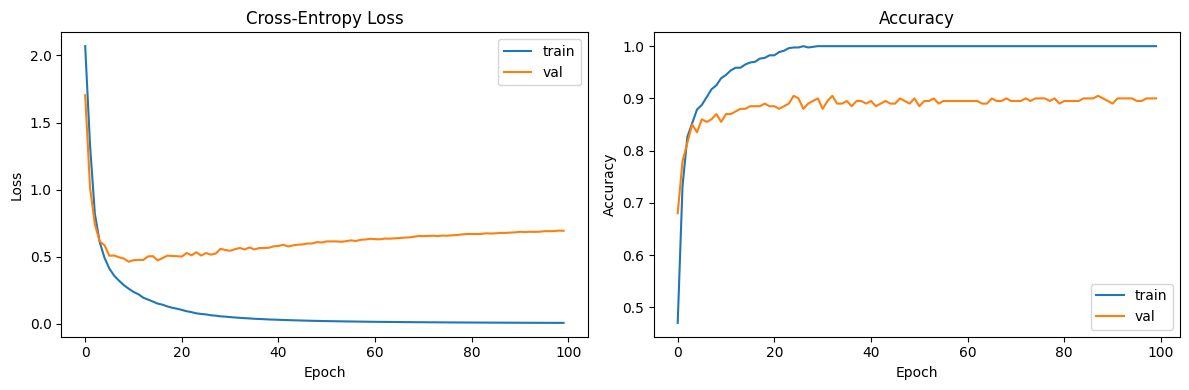

In [ ]:
# Define the model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.linear_1 = nn.Linear(in_features=..., out_features=..., bias=True)
        self.linear_2 = nn.Linear(in_features=..., out_features=..., bias=True)

    def forward(self, x):
        z1 = self.linear_1(x)
        a1 = F.relu(z1)  # equivalently: z1.clamp(min=0) or torch.max(z1, torch.tensor(0.0))
        logits = ...
        return logits

# Instantiate the model
input_size = 784
hidden_size = ...
num_classes = ...

model = MLP(input_size, hidden_size, num_classes)
learning_rate = ...

# Train the model
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(max_iter):
    # --- Training ---
    train_loss = 0.
    train_correct = 0
    train_total = 0
    for i, (x_batch, y_batch) in enumerate(train_loader):
        # Forward pass
        logits = ...
        # Compute the loss (remember that F.cross_entropy does the softmax internally)
        loss = F.cross_entropy(logits, y_batch)
        train_loss += loss.item()

        # Track accuracy
        preds = logits.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += len(y_batch)

        # Backward pass
        # Clear old gradients
        model.zero_grad()
        # Compute the gradients
        loss.backward()
        # Update the weights
        for param in model.parameters():
            param.data -= ... * param.grad

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    train_accuracies.append(train_correct / train_total)

    # --- Validation ---
    with torch.no_grad():
        val_loss = 0.
        val_correct = 0
        val_total = 0
        for x_val_batch, y_val_batch in val_loader:
            logits = ...
            val_loss += ...
            preds = logits.argmax(dim=1)
            val_correct += (preds == y_val_batch).sum().item()
            val_total += len(y_val_batch)
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        val_accuracies.append(val_correct / val_total)

    if epoch % 10 == 0 or epoch == max_iter - 1:
        print(f"Epoch {epoch:3d}: train_loss={train_loss:.3f}, val_loss={val_loss:.3f}, "
              f"train_acc={train_accuracies[-1]:.1%}, val_acc={val_accuracies[-1]:.1%}")

# Plot loss and accuracy side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='train')
ax1.plot(val_losses, label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title('Cross-Entropy Loss')
ax2.plot(train_accuracies, label='train')
ax2.plot(val_accuracies, label='val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend(); ax2.set_title('Accuracy')
plt.tight_layout()

**Make sure you can explain** what each of these lines does in the training loop:
1. `logits = model(x_batch)` — forward pass
2. `loss = F.cross_entropy(logits, y_batch)` — compute loss (includes softmax internally)
3. `model.zero_grad()` — clear gradients from previous step
4. `loss.backward()` — compute gradients via backpropagation
5. `param.data -= learning_rate * param.grad` — update weights (SGD step)

## Analyzing the Trained Model

Now that we've trained the model, let's look at what it learned:
1. Predictions on sample images
2. Where it gets confused (confusion matrix)
3. Its most confident mistakes
4. The learned weights

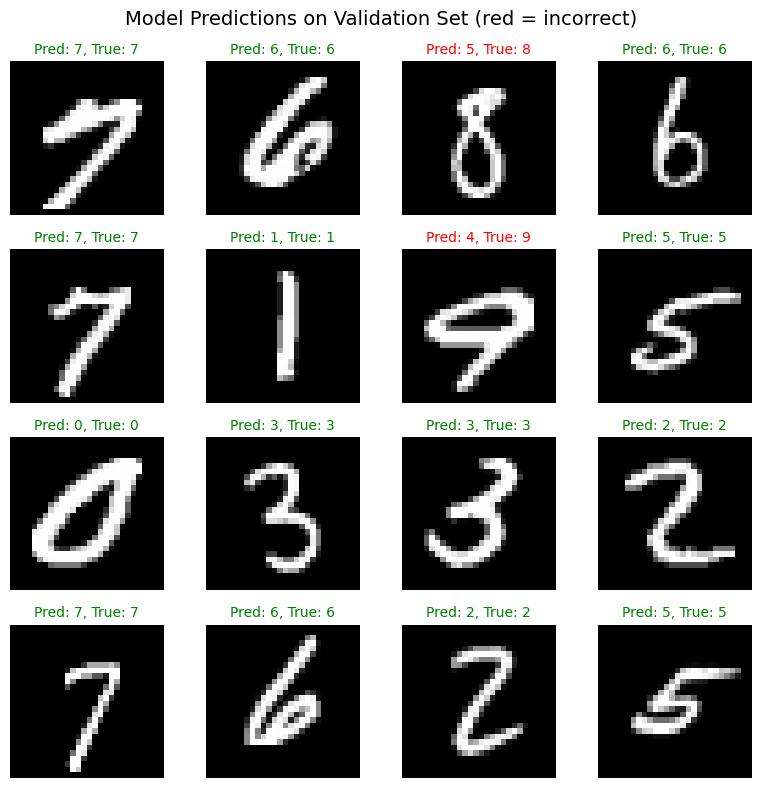

In [ ]:
# Show predictions on validation images
x_val_tensor = torch.tensor(x_val)
with torch.no_grad():
    val_logits = model(x_val_tensor)
    val_preds = val_logits.argmax(dim=1)
    val_probs = val_logits.softmax(dim=-1)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_val[i].reshape(28, 28), cmap='gray')
    pred = val_preds[i].item()
    actual = y_val[i]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f"Pred: {pred}, True: {actual}", color=color, fontsize=10)
    ax.axis('off')
fig.suptitle("Model Predictions on Validation Set (red = incorrect)", fontsize=14)
plt.tight_layout()

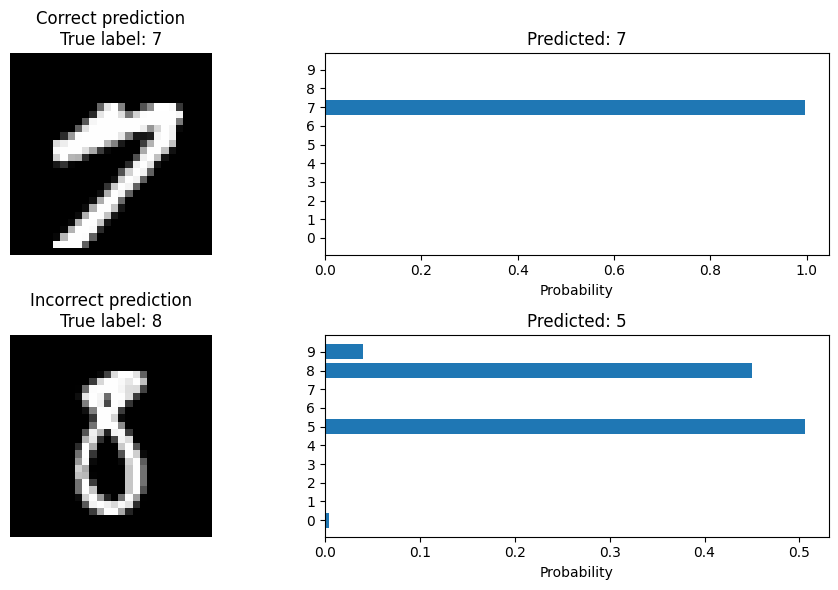

In [ ]:
# Show softmax probabilities for one correct and one incorrect prediction
correct_idx = None
incorrect_idx = None
for i in range(len(val_preds)):
    pred = val_preds[i].item()
    if pred == y_val[i] and correct_idx is None:
        correct_idx = i
    if pred != y_val[i] and incorrect_idx is None:
        incorrect_idx = i
    if correct_idx is not None and incorrect_idx is not None:
        break

indices_to_show = [i for i in [correct_idx, incorrect_idx] if i is not None]
titles = ["Correct prediction", "Incorrect prediction"]

fig, axes = plt.subplots(len(indices_to_show), 2, figsize=(10, 3 * len(indices_to_show)))
if len(indices_to_show) == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(indices_to_show):
    axes[row, 0].imshow(x_val[idx].reshape(28, 28), cmap='gray')
    axes[row, 0].set_title(f"{titles[row]}\nTrue label: {y_val[idx]}")
    axes[row, 0].axis('off')
    axes[row, 1].barh(range(10), val_probs[idx].numpy())
    axes[row, 1].set_yticks(range(10))
    axes[row, 1].set_xlabel("Probability")
    axes[row, 1].set_title(f"Predicted: {val_preds[idx].item()}")
plt.tight_layout()

### Confusion Matrix

Which digits does the model confuse with each other?

Overall validation accuracy: 90.0%


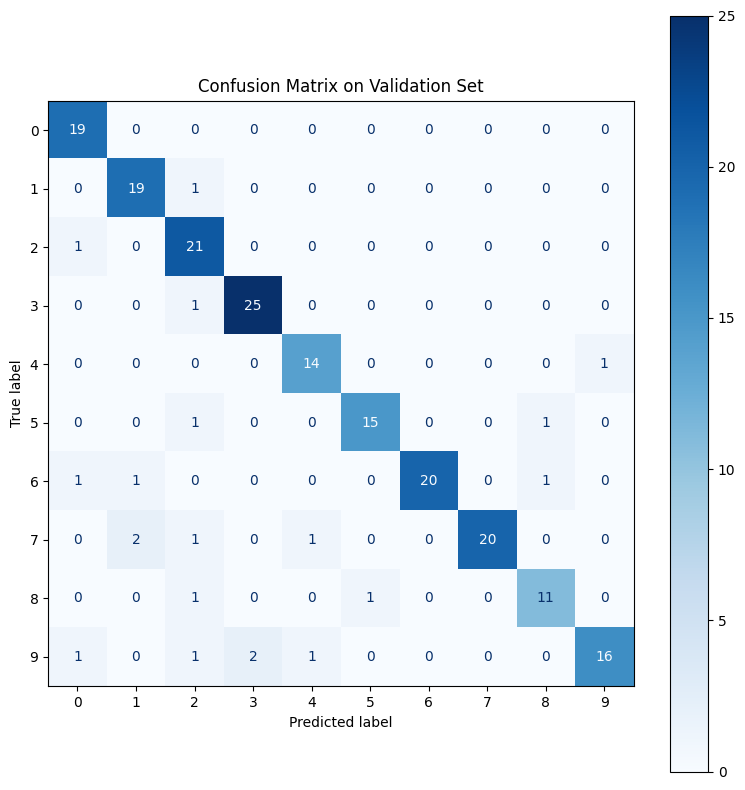

In [ ]:
cm = confusion_matrix(y_val, val_preds.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues')
ax.set_title("Confusion Matrix on Validation Set")
plt.tight_layout()

val_acc = (val_preds.numpy() == y_val).mean()
print(f"Overall validation accuracy: {val_acc:.1%}")

### Most Confident Mistakes

These are the images where the model was *most certain* about the wrong answer. These are often the most informative errors to examine.

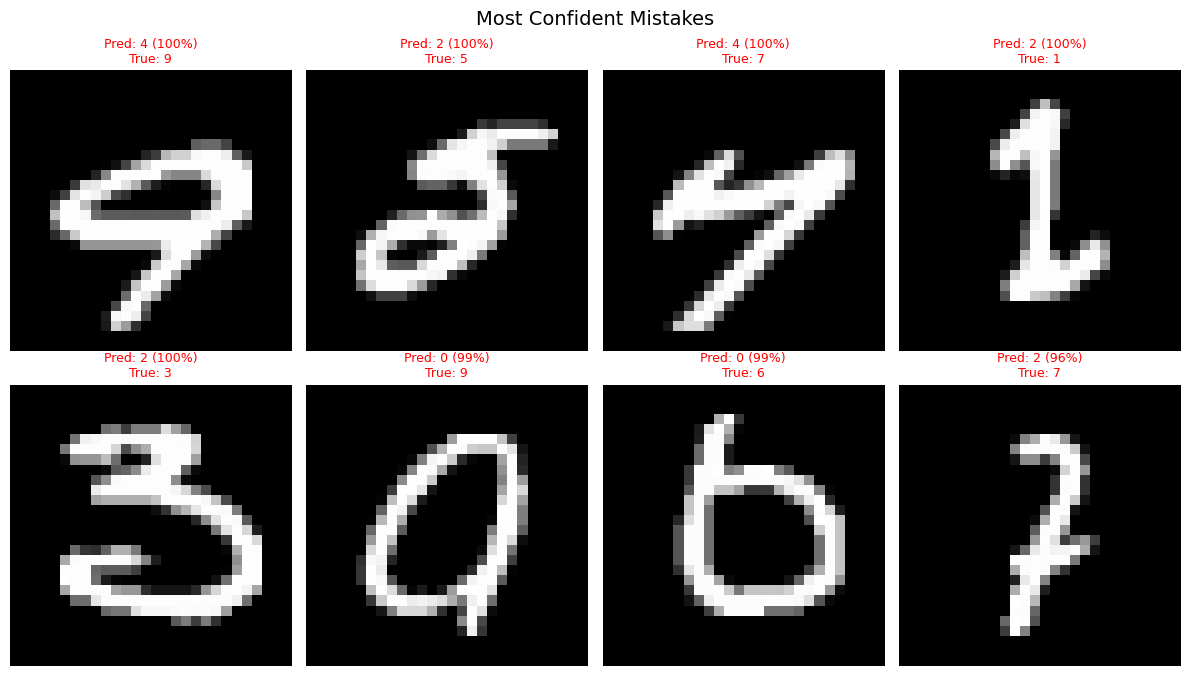

In [ ]:
# Find the most confidently wrong predictions
wrong_mask = val_preds.numpy() != y_val
if wrong_mask.sum() > 0:
    wrong_indices = np.where(wrong_mask)[0]
    # Confidence = max probability for wrong predictions
    wrong_confidences = val_probs[wrong_indices].max(dim=1).values.numpy()
    # Sort by confidence (most confident first)
    sorted_order = np.argsort(-wrong_confidences)

    n_show = min(8, len(sorted_order))
    fig, axes = plt.subplots(2, min(4, n_show), figsize=(3 * min(4, n_show), 7))
    if n_show <= 4:
        axes = axes.reshape(1, -1) if n_show > 1 else np.array([[axes]])
    for i in range(n_show):
        row, col = divmod(i, min(4, n_show))
        idx = wrong_indices[sorted_order[i]]
        ax = axes[row, col] if n_show > 4 else axes[0, i]
        ax.imshow(x_val[idx].reshape(28, 28), cmap='gray')
        conf = wrong_confidences[sorted_order[i]]
        ax.set_title(f"Pred: {val_preds[idx].item()} ({conf:.0%})\nTrue: {y_val[idx]}", color='red', fontsize=9)
        ax.axis('off')
    fig.suptitle("Most Confident Mistakes", fontsize=14)
    plt.tight_layout()
else:
    print("No mistakes found!")

### Visualizing Learned Weights

For the first layer (`linear_1`), each of the 128 output neurons has 784 weights -- one per input pixel. We can reshape these weight vectors back to 28x28 images to see what patterns each neuron has learned to detect.

> **Note**: In a multi-layer network, these weight images are harder to interpret than in a single-layer network (like logistic regression), because each hidden neuron only contributes *partially* to the final classification. Still, we can often see that neurons specialize in detecting particular strokes or patterns.

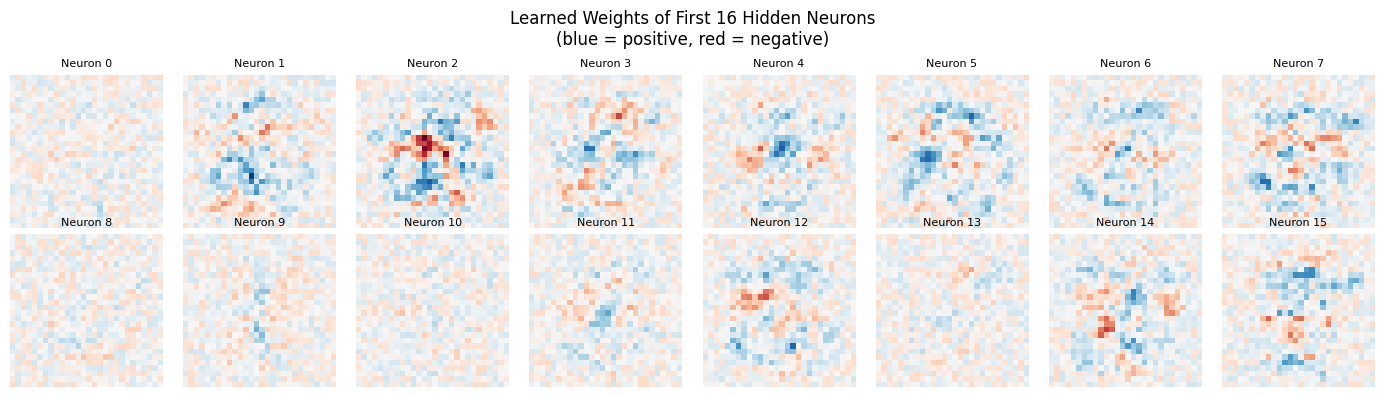

In [ ]:
# Visualize the first 16 hidden neuron weights as 28x28 images
weight_images = model.linear_1.weight.data[:16].reshape(16, 28, 28)
vmax = weight_images.abs().max()
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(weight_images[i].numpy(), cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_title(f"Neuron {i}", fontsize=8)
    ax.axis('off')
fig.suptitle("Learned Weights of First 16 Hidden Neurons\n(blue = positive, red = negative)", fontsize=12)
plt.tight_layout()

Unlike a single-layer classifier (where each weight image directly corresponds to one digit class), these hidden neurons learn *features* -- stroke patterns, edges, or partial digit shapes. The second layer (`linear_2`) then combines these features to make the final classification.

If you want to see weight images that look more like digits, try changing the model to a single layer (remove the hidden layer and ReLU) and retrain.

## Reflection Questions

**Q1**: In the training loop, if `x_batch` has shape `(32, 784)`, trace the shapes through the network:
- After `linear_1`: ?
- After ReLU: ?
- After `linear_2` (logits): ?

Explain *why* the logits have the shape they do.

*your answer here*

**Q2**: Before training (random weights), the cross-entropy loss was approximately 2.3. Why? What is the theoretical value for a 10-class classifier that assigns equal probability to all classes?

(Hint: what probability does each class get if the model is maximally uncertain?)

*your answer here*

In [ ]:
# Hint:
np.log(10)

np.float64(2.302585092994046)

**Q3**: Go back and try different learning rates. Find:
- A learning rate that is **too high** (loss diverges or oscillates wildly)
- A learning rate that is **too low** (loss barely decreases in 100 epochs)
- A learning rate that works **well**

For each, describe what the loss curve looks like and what the final accuracy is.

*your answer here*

**Q4**: Look at the weight visualizations above. Why might the hidden neurons learn patterns that look like strokes or edges? What limitation does having just a single hidden layer impose on what the network can represent?

*your answer here*

## Next Steps

- **Data augmentation**: See the supplemental notebook (`u06s2-mnist-torch-augmentation`) for how shifting images during training improves robustness.
- **Better optimizers**: Try replacing the manual SGD step with `torch.optim.SGD` or `torch.optim.Adam`.
- **More data**: Increase `num_samples` to 10000 or use the full dataset and observe how accuracy changes.